# TP1

## Exercise n°1 : Logistic regression by gradient descent

In [30]:
import numpy as np
import matplotlib.pyplot as plt

## Question 1)

In [31]:
def datagen(n):
    inputs = np.random.rand(n, 2)
    labels = np.zeros(n)

    y = -0.5*inputs[:,0] - inputs[:,1] + 0.75
    D = y/np.sqrt((-0.5)**2 + (-1)**2)
    r = 0

    for i in range(n):    
        if D[i] > 0:
            labels[i] = 1

        r = np.exp(-(D[i]**2)/ (2*0.05**2))
        z = np.random.binomial(1,r/2)

        if z == 1:
            labels[i] = 1 - labels[i]
    
    return inputs, labels

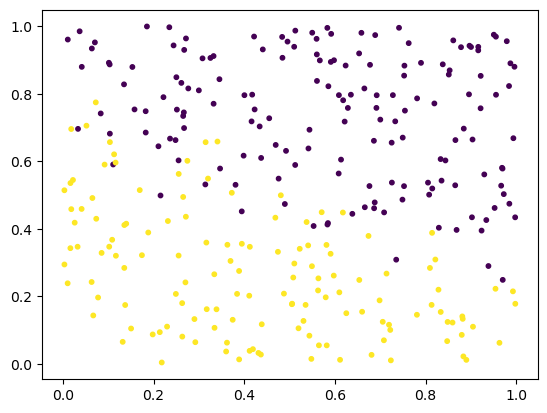

In [32]:
inputs, labels= datagen(300)
plt.scatter(inputs[:,0], inputs[:,1], c=labels, s=10)
plt.show()

## Question 2)

In [33]:
n = len(inputs)
X_plus = np.hstack((inputs,np.ones((n,1)))).T
print(X_plus.shape)

(3, 300)


## Question 3)

In [34]:
def sigmoid(X):
  return 1 / (1 + np.exp(-X))

def batch_descent(X, y, max_iter=1000, eta=1e-2, conv=1e-10):
    n_features, n_samples = X.shape

    thetas = np.zeros((max_iter + 1, n_features))
    t = 0

    g = np.ones(X.shape)

    while np.linalg.norm(g) > conv and t < max_iter:
        pred = sigmoid(X.T @ thetas[t])
        err = pred - y
        g = X @ err
        thetas[t+1] = thetas[t] - eta * g
        t += 1

    return thetas, t
    

## Question 4)

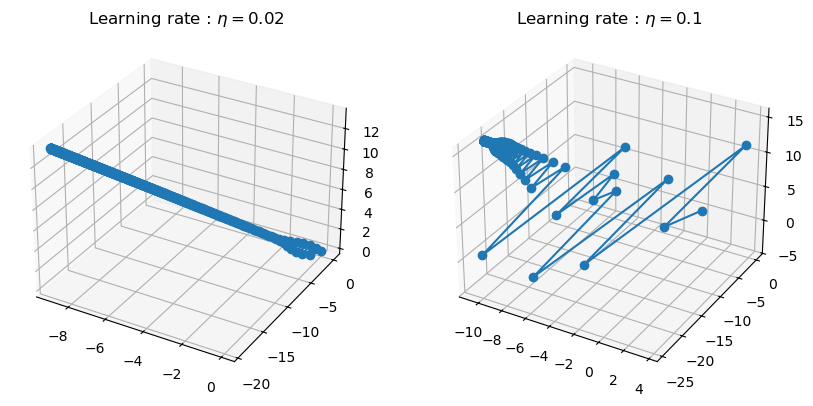

In [35]:
from mpl_toolkits.mplot3d import Axes3D

fig, axes = plt.subplots(1, 2, figsize=(10,5), subplot_kw={'projection': '3d'})

thetas_1, t1 = batch_descent(X_plus, labels, eta=0.02)

axes[0].plot(thetas_1[:, 0], thetas_1[:, 1], thetas_1[:, 2], '-o')
axes[0].set_title(r'Learning rate : $\eta = 0.02$')

thetas_2, t2 = batch_descent(X_plus, labels, eta=0.1)
axes[1].plot(thetas_2[:, 0], thetas_2[:, 1], thetas_2[:, 2], '-o')
axes[1].set_title(r'Learning rate : $\eta = 0.1$')
plt.draw()

<div class="alert alert-warning" style="margin-top: 2px">

As we seen on the previous graphs, the learning rate $\eta$ has a big influence on the trajectory of $\theta$. We noticed a stronger learning rate lead to more instability than a weaker one.

## Question 5) and modification Question 8)

In [36]:
def stochastic(X, y, batch_size=10, max_iter=1000, eta=1e-2, conv=1e-10):

    n_features, n_samples = X.shape

    thetas = np.zeros((max_iter+1, n_features))
    epochs = 0

    g = np.ones((3,batch_size))

    while np.linalg.norm(g) > conv and epochs < max_iter:
        perm = np.random.permutation(n_samples)

        X_perm = X_plus[:,perm]
        y_perm = y[perm]

        #Answer to the 8th question with the mini-batch
        for i in range(0, n_samples, batch_size):

            X_batch = X_perm[:,i:i+batch_size]
            y_batch = y_perm[i:i+batch_size]
            
            pred = sigmoid(X_batch.T @ thetas[epochs])
            err = pred - y_batch
            g = X_batch @ err

            thetas[epochs+1] = thetas[epochs] - eta * g

        epochs += 1

    return thetas, epochs

## Question 6)

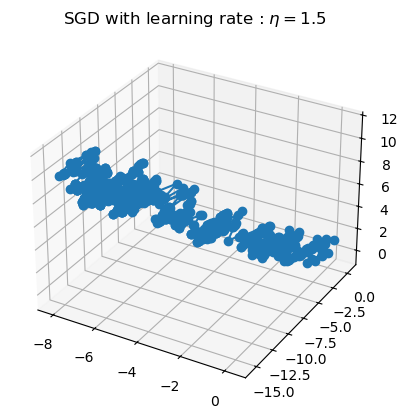

In [37]:
thetas, epochs = stochastic(X_plus, labels, batch_size=1, eta=1.5)

fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.plot(thetas[:,0],thetas[:,1],thetas[:,2],'-o')
ax.set_title(r"SGD with learning rate : $\eta = 1.5$")
plt.draw()

<div class="alert alert-warning" style="margin-top: 2px">

We observe large oscillations with a high learning rate. It can be explained by how the stochastic works. Indeed, it uses the noisy gradients which more sensitive to the learning rate 

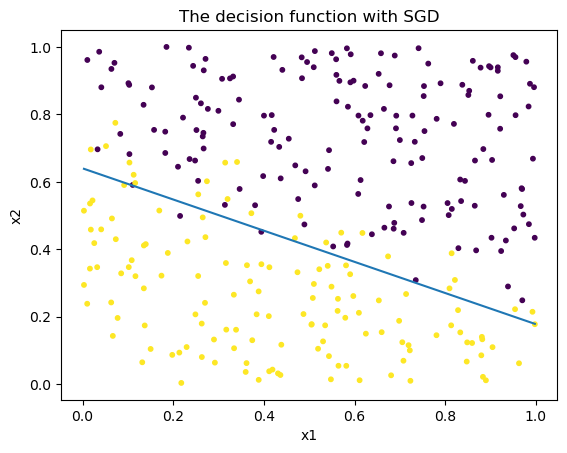

In [38]:
x1_min, x1_max = inputs[:, 0].min(), inputs[:, 0].max()
x1 = np.linspace(x1_min, x1_max, 200)

theta = thetas[-1]

x2 = -(theta[0] * x1 + theta[2]) / theta[1]

plt.scatter(inputs[:, 0], inputs[:, 1], c=labels, s=10)
plt.plot(x1, x2)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("The decision function with SGD")
plt.show()

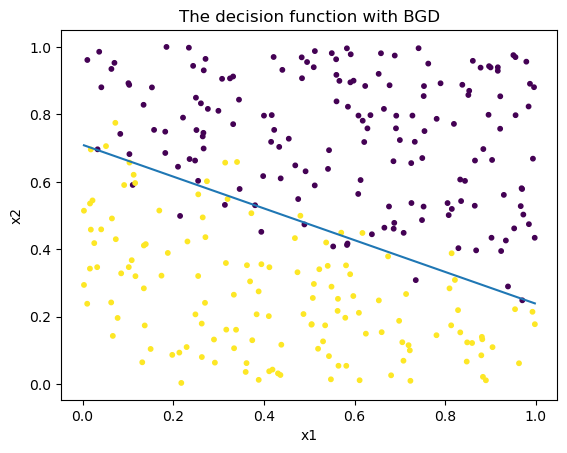

In [39]:
thetas , iterations = batch_descent(X_plus, labels, eta=0.02)

# Retrieve the last weights learned
theta = thetas[-1]

x2 = -(theta[0] * x1 + theta[2]) / theta[1]

plt.scatter(inputs[:, 0], inputs[:, 1], c=labels, s=10)
plt.plot(x1, x2)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("The decision function with BGD")
plt.show()

## Question 8)

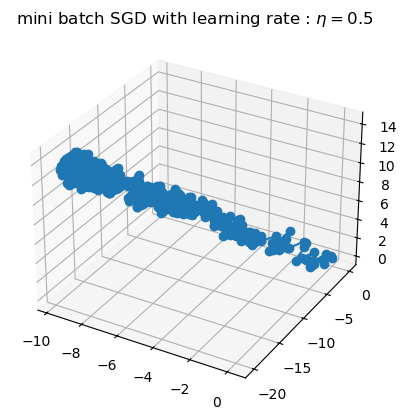

In [40]:
thetas, epochs = stochastic(X_plus, labels, batch_size=10, eta=0.5)

fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.plot(thetas[:,0],thetas[:,1],thetas[:,2],'-o')
ax.set_title(r"mini batch SGD with learning rate : $\eta = 0.5$")
plt.draw()

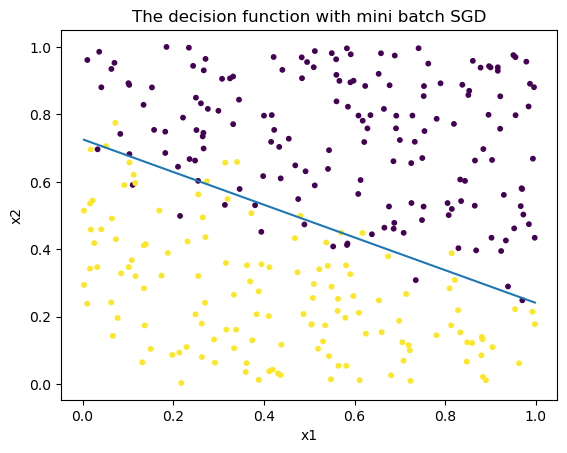

In [41]:
theta = thetas[-1]

x2 = -(theta[0] * x1 + theta[2]) / theta[1]

plt.scatter(inputs[:, 0], inputs[:, 1], c=labels, s=10)
plt.plot(x1, x2)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("The decision function with mini batch SGD")
plt.show()